# Grokking baseline with decay -- 3-axis knob sweep

Direct follow-up to [`manifold_and_ablation.ipynb`](manifold_and_ablation.ipynb).  Two negatives surfaced from that notebook and from [`fourier_decomp.ipynb`](fourier_decomp.ipynb):

1. **Per-neuron sum-of-angles trig-identity score collapsed to 0** for both periodic and polynomial teachers (`median = 0.000`, `frac > 0.5 = 0.031`).  The aggregate `cos_cos` channel dominates the trunk, but no individual neuron pairs `cos x cos y` with `-sin x sin y` cleanly.
2. **Baseline SIREN trunk did not learn the Anthropic-style helix on its own** (`best_r2_i = +0.457`, `wrap_i / 2 pi = 0`); only the variants whose architecture (`B_fourier`, `C_factored`) or auxiliary loss (`A_axis_loss`) explicitly primed the Fourier representation got the helix.

The hypothesis is that three classical grokking ingredients are absent from the current setup: **weight decay** (the OpenAI paper's central knob, currently `weight_decay = 0.0`), an actual **lattice holdout** (currently every lattice cell is supervised; [`train.py:9-10`](../../../sobolev_distill_character/train.py) explicitly defers this to the caller), and a long enough **epoch budget** to enter the cleanup phase (currently 2000 epochs, vs ~7000 in Nanda's transformer at p = 113).

Sections: §1 imports + config, §2 grid + teachers, §3 holdout helpers, §4 training + probe driver, §5 p = 8 sweep loop (27 rows), §6 p = 17 confirmation row, §7 result table, §8 diagnostic plots, §9 takeaway.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import math
import sys
import time
from dataclasses import replace
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


def _polys_root_for_import() -> Path:
    here = Path.cwd().resolve()
    candidates = [
        here / 'graphic_zero_character',
        here.parent / 'graphic_zero_character',
        here.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent.parent / 'graphic_zero_character',
    ]
    for g in candidates:
        if g.is_dir() and (g / '__init__.py').exists():
            return g.parent
    raise FileNotFoundError('Could not locate ml/polys.')


_polys = _polys_root_for_import()
if str(_polys) not in sys.path:
    sys.path.insert(0, str(_polys))

from sobolev_distill_character import (
    CharacterStudentConfig,
    CharacterTrainConfig,
    LinearRampSchedule,
    LossWeights,
    build_character_dataset,
    build_character_teacher_mesh_periodic,
    compute_latents_character,
    dft_trunk_along_axis,
    fft2_neuron_surface,
    helix_pca,
    linear_probes_character,
    make_character_student,
    train_student_character_scheduled,
)
from sobolev_distill_character.train import _lattice_modular_truth_recovered

print('jax devices:', jax.devices())

jax devices: [CudaDevice(id=0)]


E0515 13:53:17.382454   63807 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0515 13:53:17.393398   63649 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [2]:
STUDENT_CFG = CharacterStudentConfig(
    trunk_hidden=64,
    trunk_depth=3,
    embed_dim=32,
    head_hidden=32,
    activation='siren',
    omega_0=2.5,
    axis_probe=False,
)

WEIGHTS_BASE = LossWeights(
    value=1.0, grad=0.0, hess=0.0, hess_reg=1e-4,
    unit_circle=0.5, axis=0.0, energy_value=0.5,
    energy_pd=0.0, pd_pos_weight=1.0,
)

BATCH_SIZE = 256
LATTICE_FRAC = 0.4
CHEBYSHEV_FRAC = 0.4
LR_INIT = 1e-3
LR_MIN = 1e-5
GRAD_CLIP = 1.0
GRAD_RAMP_END = 0.05

P8_MODULUS, P8_MAX_N, P8_MESH_N = 8, 8, 64
P17_MODULUS, P17_MAX_N, P17_MESH_N = 17, 17, 64

RAMP_EPOCHS_OF = lambda epochs_total: max(200, epochs_total // 10)

print('student is baseline_siren (axis_probe=False, weights.axis=0.0); the only sweep knobs are weight_decay, train_frac, epochs.')

student is baseline_siren (axis_probe=False, weights.axis=0.0); the only sweep knobs are weight_decay, train_frac, epochs.


## 2. Grid definition + periodic teachers

27 rows at p = 8 (`weight_decay` x `train_frac` x `epochs` = 3 x 3 x 3) plus a single confirmation row at p = 17 at the corner expected to grok cleanly.  At ~120 s per 2000-epoch p = 8 run on the current device, the wall-clock budget is roughly `9 * (2000 + 8000 + 20000) / 2000 * 120 s` ≈ 4.5 h plus ~8 min at p = 17.

In [3]:
WEIGHT_DECAYS = [0.0, 0.01, 0.1]
TRAIN_FRACS   = [1.0, 0.5, 0.3]
EPOCH_BUDGETS = [2000, 8000, 20000]

P17_CONFIRMATION = dict(weight_decay=0.01, train_frac=0.3, epochs=8000)

n_p8_rows = len(WEIGHT_DECAYS) * len(TRAIN_FRACS) * len(EPOCH_BUDGETS)
print(f'grid: {len(WEIGHT_DECAYS)} weight_decays x {len(TRAIN_FRACS)} train_fracs x {len(EPOCH_BUDGETS)} epoch_budgets = {n_p8_rows} rows at p={P8_MODULUS}, plus 1 row at p={P17_MODULUS}')

grid: 3 weight_decays x 3 train_fracs x 3 epoch_budgets = 27 rows at p=8, plus 1 row at p=17


In [4]:
def _build_full_dataset(p, max_n, mesh_n):
    nodes = np.arange(max_n, dtype=np.float64)
    teacher_ = build_character_teacher_mesh_periodic(
        nodes_x=nodes, nodes_y=nodes, p=p, mesh_n=mesh_n, lam=1.0,
    )
    ds_ = build_character_dataset(teacher_)
    return teacher_, ds_

teacher_p8, ds_p8 = _build_full_dataset(P8_MODULUS, P8_MAX_N, P8_MESH_N)
teacher_p17, ds_p17 = _build_full_dataset(P17_MODULUS, P17_MAX_N, P17_MESH_N)

print(f'p={P8_MODULUS}  N={ds_p8.n}  K_lat={int(np.asarray(ds_p8.is_node).sum())}')
print(f'p={P17_MODULUS} N={ds_p17.n}  K_lat={int(np.asarray(ds_p17.is_node).sum())}')

p=8  N=4096  K_lat=64
p=17 N=6241  K_lat=289


## 3. Lattice holdout helpers

`make_train_holdout_split` drops a deterministic random fraction of lattice rows from the dataset entirely so the minibatch sampler in [`train.py`](../../../sobolev_distill_character/train.py) cannot reach them through *any* of its three quotas (lattice / chebyshev / uniform).  The original (full) dataset is retained for evaluation so probes still see every lattice cell.

`eval_modular_accuracy_split` runs `_lattice_modular_truth_recovered` on the trained student against the **full** dataset and uses the row-index lists returned by the split to score train and holdout cells separately.  When `train_frac == 1.0` the holdout list is empty and `hold_acc` is reported as `nan`.

In [5]:
_PER_ROW_FIELDS = (
    'xy', 'xy_raw',
    'V_re', 'V_im',
    'GX_re', 'GX_im', 'GY_re', 'GY_im',
    'Hxx_re', 'Hxx_im', 'Hxy_re', 'Hxy_im', 'Hyy_re', 'Hyy_im',
    'V_M', 'is_node', 'is_pd', 'cheb_weight',
    'axis_target_cos_x', 'axis_target_sin_x',
    'axis_target_cos_y', 'axis_target_sin_y',
)


def make_train_holdout_split(dataset, train_frac, *, seed=0):
    """Drop a random fraction of lattice rows from ``dataset``.

    Returns ``(train_dataset, lat_full, train_lat, hold_lat)`` where
    ``train_dataset`` is the masked dataset to *train* on and ``train_lat`` /
    ``hold_lat`` are row indices into the original ``dataset.is_node`` rows
    used at evaluation time.  When ``train_frac == 1.0`` the function
    returns the original dataset and an empty ``hold_lat``.
    """
    is_node = np.asarray(dataset.is_node)
    lat_full = np.where(is_node)[0]
    n_lat = int(lat_full.size)
    rng = np.random.default_rng(int(seed))
    perm = rng.permutation(n_lat)
    n_train = int(round(float(train_frac) * n_lat))
    n_train = max(1, min(n_lat, n_train))
    train_lat = np.sort(lat_full[perm[:n_train]])
    hold_lat  = np.sort(lat_full[perm[n_train:]])

    if hold_lat.size == 0:
        return dataset, lat_full, train_lat, hold_lat

    keep = np.ones(int(dataset.xy.shape[0]), dtype=bool)
    keep[hold_lat] = False
    masked = {k: getattr(dataset, k)[keep] for k in _PER_ROW_FIELDS}
    train_dataset = replace(dataset, **masked)
    return train_dataset, lat_full, train_lat, hold_lat


def eval_modular_accuracy_split(student, full_dataset, teacher, train_lat, hold_lat):
    """Train / holdout modular accuracy + unit-circle residual on ``full_dataset``."""
    lat_idx, _i, _j, truth, recovered, complex_pred = _lattice_modular_truth_recovered(
        student, full_dataset, teacher,
    )
    pos = {int(r): k for k, r in enumerate(lat_idx)}
    train_pos = np.array([pos[int(r)] for r in train_lat], dtype=np.int64)
    hold_pos  = np.array([pos[int(r)] for r in hold_lat],  dtype=np.int64)
    train_acc = float((recovered[train_pos] == truth[train_pos]).mean()) if train_pos.size else float('nan')
    hold_acc  = float((recovered[hold_pos]  == truth[hold_pos]).mean())  if hold_pos.size  else float('nan')
    gap = (train_acc - hold_acc) if hold_pos.size else float('nan')
    return {
        'train_acc': train_acc,
        'hold_acc':  hold_acc,
        'gap':       gap,
        'unit':      float(np.abs(np.abs(complex_pred) - 1.0).mean()),
        'modular_acc_full': float((recovered == truth).mean()),
    }


_train_smoke, lat_full_smoke, train_lat_smoke, hold_lat_smoke = make_train_holdout_split(
    ds_p8, train_frac=0.5, seed=0,
)
print(f'split smoke: full N={ds_p8.n}  train N={_train_smoke.n}  '
      f'lat total={lat_full_smoke.size}  train_lat={train_lat_smoke.size}  hold_lat={hold_lat_smoke.size}')

split smoke: full N=4096  train N=4064  lat total=64  train_lat=32  hold_lat=32


## 4. Training + probe driver

One call to `train_one(weight_decay, train_frac, epochs, *, p, max_n, mesh_n, ...)` performs:

1. Build the periodic teacher + dataset (cached per `p` to avoid re-evaluating the mesh).
2. Apply the lattice holdout split.
3. Train `baseline_siren` on the masked dataset with the supplied `weight_decay` and `epochs`, ramping `weights.grad` from 0 to `GRAD_RAMP_END` over `RAMP_EPOCHS_OF(epochs)`.
4. Probe the trained student on the **full** dataset: `helix_pca` (i and j), `fft2_neuron_surface` for the per-neuron sum-of-angles score, `dft_trunk_along_axis` for the 1-D mode histogram, `linear_probes_character` for the standard `R^2` table, and `eval_modular_accuracy_split` for train / holdout / gap.

In [6]:
def train_one(
    weight_decay,
    train_frac,
    epochs,
    *,
    teacher,
    full_dataset,
    seed=0,
):
    train_dataset, _lat_full, train_lat, hold_lat = make_train_holdout_split(
        full_dataset, train_frac=train_frac, seed=seed,
    )
    student = make_character_student(jax.random.PRNGKey(seed), STUDENT_CFG)
    cfg = CharacterTrainConfig(
        epochs=int(epochs),
        batch_size=BATCH_SIZE,
        lr_init=LR_INIT,
        lr_min=LR_MIN,
        weight_decay=float(weight_decay),
        grad_clip=GRAD_CLIP,
        lattice_frac=LATTICE_FRAC,
        chebyshev_frac=CHEBYSHEV_FRAC,
        weights=WEIGHTS_BASE,
        log_every=max(50, int(epochs) // 20),
        seed=int(seed),
    )
    schedule = LinearRampSchedule(
        base=WEIGHTS_BASE, field='grad',
        start=0.0, end=GRAD_RAMP_END, ramp_epochs=RAMP_EPOCHS_OF(int(epochs)),
    )
    t0 = time.time()
    student, _hist = train_student_character_scheduled(
        student, train_dataset, cfg, schedule,
    )
    train_s = time.time() - t0

    diag = eval_modular_accuracy_split(student, full_dataset, teacher, train_lat, hold_lat)
    latents = compute_latents_character(student, full_dataset, teacher)
    probes  = linear_probes_character(latents)
    rep_i   = helix_pca(latents, axis='i', n_components=6)
    rep_j   = helix_pca(latents, axis='j', n_components=6)
    fft2    = fft2_neuron_surface(student, full_dataset, teacher)
    dft0    = dft_trunk_along_axis(student, full_dataset, teacher, axis=0)

    soa = np.asarray(fft2.sum_of_angles_score)
    chan_keys = ('cos_cos', 'sin_sin', 'cos_sin', 'sin_cos')
    chan_totals = {k: float(fft2.channel_energy[k].sum()) for k in chan_keys}
    chan_norm = sum(chan_totals.values()) or 1.0
    chan_frac = {k: v / chan_norm for k, v in chan_totals.items()}

    p = int(teacher.modulus)
    nyq = max(1, p // 2)
    agg_mag = np.asarray(dft0.magnitude)[:, 1:nyq + 1].sum(axis=0)
    top_modes = (np.argsort(-agg_mag)[:3] + 1).tolist()

    return {
        'p': p,
        'weight_decay': float(weight_decay),
        'train_frac':   float(train_frac),
        'epochs':       int(epochs),
        'train_s':      float(train_s),
        'modular_acc_full': diag['modular_acc_full'],
        'train_acc':    diag['train_acc'],
        'hold_acc':     diag['hold_acc'],
        'gap':          diag['gap'],
        'unit':         diag['unit'],
        'r2_T':         float(probes.r2.get('Re T[i,j]', float('nan'))),
        'r2_zi':        float(probes.r2.get('Re zeta^i', float('nan'))),
        'r2_zj':        float(probes.r2.get('Re zeta^j', float('nan'))),
        'best_k_i':     int(rep_i.best_k),
        'helix_r2_i':   float(rep_i.best_r2),
        'wrap_i':       float(rep_i.wrap_angle_radians),
        'best_k_j':     int(rep_j.best_k),
        'helix_r2_j':   float(rep_j.best_r2),
        'wrap_j':       float(rep_j.wrap_angle_radians),
        'soa_median':   float(np.median(soa)),
        'soa_mean':     float(soa.mean()),
        'soa_frac_gt_half': float((soa > 0.5).mean()),
        'cos_cos_frac': chan_frac['cos_cos'],
        'sin_sin_frac': chan_frac['sin_sin'],
        'cos_sin_frac': chan_frac['cos_sin'],
        'sin_cos_frac': chan_frac['sin_cos'],
        'top_modes':    top_modes,
    }

## 5. p = 8 sweep loop

27 cells, one per `(weight_decay, train_frac, epochs)` triple.  The triples are split into individual cells so each row's output commits to the notebook file as soon as the row completes; that is the only way to observe progress mid-sweep through the saved `.ipynb`.  Long rows (`epochs = 20000`) take ~20 minutes apiece on the current device, so the full p = 8 sweep is ~4.5 h.  The per-row status format is

```
wd=0.01 frac=0.30 ep=8000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.91 wrap_i/2pi=+1.00 | soa_med=0.34 frac>0.5=0.28 cos_cos=0.51 | t=480.2s
```

In [7]:
rows_p8 = []
n_total_p8 = len(WEIGHT_DECAYS) * len(TRAIN_FRACS) * len(EPOCH_BUDGETS)
print(f'p={P8_MODULUS} sweep: {n_total_p8} rows queued')

p=8 sweep: 27 rows queued


In [8]:
_row_idx = 1
_wd, _tf, _ep = 0.0, 1.0, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 1/27] training wd=0.0  frac=1.00  ep=2000 ...


    wd=  0.0  frac=1.00  ep= 2000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.46 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.16 cos_cos=0.55 | t=540.6s


In [9]:
_row_idx = 2
_wd, _tf, _ep = 0.0, 1.0, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 2/27] training wd=0.0  frac=1.00  ep=8000 ...


    wd=  0.0  frac=1.00  ep= 8000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.46 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.16 cos_cos=0.47 | t=555.7s


In [10]:
_row_idx = 3
_wd, _tf, _ep = 0.0, 1.0, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 3/27] training wd=0.0  frac=1.00  ep=20000 ...


    wd=  0.0  frac=1.00  ep=20000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.46 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.28 cos_cos=0.52 | t=1108.8s


In [11]:
_row_idx = 4
_wd, _tf, _ep = 0.0, 0.5, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 4/27] training wd=0.0  frac=0.50  ep=2000 ...


    wd=  0.0  frac=0.50  ep= 2000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.65 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.22 cos_cos=0.35 | t=121.9s


In [12]:
_row_idx = 5
_wd, _tf, _ep = 0.0, 0.5, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 5/27] training wd=0.0  frac=0.50  ep=8000 ...


    wd=  0.0  frac=0.50  ep= 8000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.63 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.31 cos_cos=0.41 | t=453.9s


In [13]:
_row_idx = 6
_wd, _tf, _ep = 0.0, 0.5, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 6/27] training wd=0.0  frac=0.50  ep=20000 ...


    wd=  0.0  frac=0.50  ep=20000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.58 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.16 cos_cos=0.47 | t=1089.4s


In [14]:
_row_idx = 7
_wd, _tf, _ep = 0.0, 0.3, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 7/27] training wd=0.0  frac=0.30  ep=2000 ...


    wd=  0.0  frac=0.30  ep= 2000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.63 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.41 cos_cos=0.45 | t=119.7s


In [15]:
_row_idx = 8
_wd, _tf, _ep = 0.0, 0.3, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 8/27] training wd=0.0  frac=0.30  ep=8000 ...


    wd=  0.0  frac=0.30  ep= 8000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.33 wrap_i/2pi=+0.00 | soa_med=0.52 frac>0.5=0.50 cos_cos=0.60 | t=445.1s


In [16]:
_row_idx = 9
_wd, _tf, _ep = 0.0, 0.3, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[ 9/27] training wd=0.0  frac=0.30  ep=20000 ...


    wd=  0.0  frac=0.30  ep=20000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.32 wrap_i/2pi=+0.00 | soa_med=0.42 frac>0.5=0.47 cos_cos=0.57 | t=1038.0s


In [17]:
_row_idx = 10
_wd, _tf, _ep = 0.01, 1.0, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[10/27] training wd=0.01  frac=1.00  ep=2000 ...


    wd= 0.01  frac=1.00  ep= 2000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.46 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.19 cos_cos=0.55 | t=107.3s


In [18]:
_row_idx = 11
_wd, _tf, _ep = 0.01, 1.0, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[11/27] training wd=0.01  frac=1.00  ep=8000 ...


    wd= 0.01  frac=1.00  ep= 8000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.46 wrap_i/2pi=+1.00 | soa_med=0.00 frac>0.5=0.19 cos_cos=0.51 | t=407.8s


In [19]:
_row_idx = 12
_wd, _tf, _ep = 0.01, 1.0, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[12/27] training wd=0.01  frac=1.00  ep=20000 ...


    wd= 0.01  frac=1.00  ep=20000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.38 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.31 cos_cos=0.53 | t=1013.2s


In [20]:
_row_idx = 13
_wd, _tf, _ep = 0.01, 0.5, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[13/27] training wd=0.01  frac=0.50  ep=2000 ...


    wd= 0.01  frac=0.50  ep= 2000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.64 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.22 cos_cos=0.35 | t=111.6s


In [21]:
_row_idx = 14
_wd, _tf, _ep = 0.01, 0.5, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[14/27] training wd=0.01  frac=0.50  ep=8000 ...


    wd= 0.01  frac=0.50  ep= 8000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.65 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.31 cos_cos=0.40 | t=410.5s


In [22]:
_row_idx = 15
_wd, _tf, _ep = 0.01, 0.5, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[15/27] training wd=0.01  frac=0.50  ep=20000 ...


    wd= 0.01  frac=0.50  ep=20000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.58 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.25 cos_cos=0.46 | t=1009.0s


In [23]:
_row_idx = 16
_wd, _tf, _ep = 0.01, 0.3, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[16/27] training wd=0.01  frac=0.30  ep=2000 ...


    wd= 0.01  frac=0.30  ep= 2000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.63 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.41 cos_cos=0.45 | t=110.9s


In [24]:
_row_idx = 17
_wd, _tf, _ep = 0.01, 0.3, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[17/27] training wd=0.01  frac=0.30  ep=8000 ...


    wd= 0.01  frac=0.30  ep= 8000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.33 wrap_i/2pi=+0.00 | soa_med=0.02 frac>0.5=0.44 cos_cos=0.59 | t=408.8s


In [25]:
_row_idx = 18
_wd, _tf, _ep = 0.01, 0.3, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[18/27] training wd=0.01  frac=0.30  ep=20000 ...


    wd= 0.01  frac=0.30  ep=20000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.30 wrap_i/2pi=+0.00 | soa_med=0.24 frac>0.5=0.47 cos_cos=0.56 | t=1098.2s


In [26]:
_row_idx = 19
_wd, _tf, _ep = 0.1, 1.0, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[19/27] training wd=0.1  frac=1.00  ep=2000 ...


    wd=  0.1  frac=1.00  ep= 2000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.52 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.09 cos_cos=0.51 | t=132.3s


In [27]:
_row_idx = 20
_wd, _tf, _ep = 0.1, 1.0, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[20/27] training wd=0.1  frac=1.00  ep=8000 ...


    wd=  0.1  frac=1.00  ep= 8000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.48 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.22 cos_cos=0.51 | t=449.5s


In [28]:
_row_idx = 21
_wd, _tf, _ep = 0.1, 1.0, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[21/27] training wd=0.1  frac=1.00  ep=20000 ...


    wd=  0.1  frac=1.00  ep=20000  | train=1.000 hold=nan gap=+nan | helix_r2_i=+0.43 wrap_i/2pi=+1.00 | soa_med=0.00 frac>0.5=0.22 cos_cos=0.52 | t=1087.7s


In [29]:
_row_idx = 22
_wd, _tf, _ep = 0.1, 0.5, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[22/27] training wd=0.1  frac=0.50  ep=2000 ...


    wd=  0.1  frac=0.50  ep= 2000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.69 wrap_i/2pi=+1.00 | soa_med=0.00 frac>0.5=0.34 cos_cos=0.36 | t=120.1s


In [30]:
_row_idx = 23
_wd, _tf, _ep = 0.1, 0.5, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[23/27] training wd=0.1  frac=0.50  ep=8000 ...


    wd=  0.1  frac=0.50  ep= 8000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.64 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.34 cos_cos=0.41 | t=440.6s


In [31]:
_row_idx = 24
_wd, _tf, _ep = 0.1, 0.5, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[24/27] training wd=0.1  frac=0.50  ep=20000 ...


    wd=  0.1  frac=0.50  ep=20000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.51 wrap_i/2pi=-1.00 | soa_med=0.00 frac>0.5=0.34 cos_cos=0.47 | t=1110.6s


In [32]:
_row_idx = 25
_wd, _tf, _ep = 0.1, 0.3, 2000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[25/27] training wd=0.1  frac=0.30  ep=2000 ...


    wd=  0.1  frac=0.30  ep= 2000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.63 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.44 cos_cos=0.43 | t=126.3s


In [33]:
_row_idx = 26
_wd, _tf, _ep = 0.1, 0.3, 8000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[26/27] training wd=0.1  frac=0.30  ep=8000 ...


    wd=  0.1  frac=0.30  ep= 8000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.48 wrap_i/2pi=+0.00 | soa_med=0.00 frac>0.5=0.19 cos_cos=0.48 | t=467.5s


In [34]:
_row_idx = 27
_wd, _tf, _ep = 0.1, 0.3, 20000
print(f'[{_row_idx:>2d}/27] training wd={_wd}  frac={_tf:.2f}  ep={_ep} ...', flush=True)
row = train_one(_wd, _tf, _ep, teacher=teacher_p8, full_dataset=ds_p8, seed=0)
rows_p8.append(row)
print(
    f'    wd={_wd:>5}  frac={_tf:.2f}  ep={_ep:>5d}  | '
    f'train={row["train_acc"]:.3f} hold={row["hold_acc"]:.3f} '
    f'gap={row["gap"]:+.3f} | '
    f'helix_r2_i={row["helix_r2_i"]:+.2f} wrap_i/2pi={row["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row["soa_median"]:.2f} frac>0.5={row["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row["cos_cos_frac"]:.2f} | t={row["train_s"]:.1f}s',
    flush=True,
)

[27/27] training wd=0.1  frac=0.30  ep=20000 ...


    wd=  0.1  frac=0.30  ep=20000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.45 wrap_i/2pi=-1.00 | soa_med=0.39 frac>0.5=0.50 cos_cos=0.49 | t=1081.9s


In [35]:
print(f'completed {len(rows_p8)} p={P8_MODULUS} rows')

completed 27 p=8 rows


## 6. p = 17 confirmation row

Single run at p = 17 with the grid corner most likely to grok cleanly under the hypothesis (non-zero `weight_decay`, real lattice holdout, longer epoch budget).  The point is to check that whatever clears the per-neuron trig score at p = 8 also clears it at the larger lattice where there is structurally more room for `cos x cos y` and `sin x sin y` neurons to coexist (8 non-DC modes vs 4 at p = 8).

In [36]:
row_p17 = train_one(
    weight_decay=P17_CONFIRMATION['weight_decay'],
    train_frac=P17_CONFIRMATION['train_frac'],
    epochs=P17_CONFIRMATION['epochs'],
    teacher=teacher_p17,
    full_dataset=ds_p17,
    seed=0,
)
print(
    f'p={P17_MODULUS} confirmation: '
    f'wd={row_p17["weight_decay"]}  frac={row_p17["train_frac"]:.2f}  ep={row_p17["epochs"]}  | '
    f'train={row_p17["train_acc"]:.3f} hold={row_p17["hold_acc"]:.3f} gap={row_p17["gap"]:+.3f} | '
    f'helix_r2_i={row_p17["helix_r2_i"]:+.2f} wrap_i/2pi={row_p17["wrap_i"] / (2 * math.pi):+.2f} | '
    f'soa_med={row_p17["soa_median"]:.2f} frac>0.5={row_p17["soa_frac_gt_half"]:.2f} '
    f'cos_cos={row_p17["cos_cos_frac"]:.2f} | t={row_p17["train_s"]:.1f}s'
)

p=17 confirmation: wd=0.01  frac=0.30  ep=8000  | train=1.000 hold=1.000 gap=+0.000 | helix_r2_i=+0.67 wrap_i/2pi=-1.00 | soa_med=0.91 frac>0.5=0.88 cos_cos=0.54 | t=447.8s


## 7. Result table

All 28 rows side-by-side, sorted lexicographically by `(weight_decay, train_frac, epochs)` for the p = 8 grid, with the p = 17 confirmation row appended at the bottom.

In [37]:
all_rows = list(rows_p8) + [row_p17]

header = (
    f"{'p':>3s} | {'wd':>5s} | {'frac':>4s} | {'epochs':>6s} | "
    f"{'train':>5s} | {'hold':>5s} | {'gap':>6s} | {'unit':>6s} | "
    f"{'helix_r2_i':>10s} | {'wrap_i/2pi':>10s} | {'k_i':>3s} | "
    f"{'soa_med':>7s} | {'soa>0.5':>7s} | {'cc':>5s} | {'ss':>5s} | "
    f"{'r2_T':>6s} | {'t(s)':>6s}"
)
print(header)
print('-' * len(header))
for r in all_rows:
    hold_s = f"{r['hold_acc']:5.3f}" if not math.isnan(r['hold_acc']) else '  nan'
    gap_s  = f"{r['gap']:+6.3f}"     if not math.isnan(r['gap']) else '   nan'
    print(
        f"{r['p']:>3d} | {r['weight_decay']:>5} | {r['train_frac']:>4.2f} | {r['epochs']:>6d} | "
        f"{r['train_acc']:5.3f} | {hold_s} | {gap_s} | {r['unit']:6.4f} | "
        f"{r['helix_r2_i']:+10.3f} | {r['wrap_i'] / (2 * math.pi):+10.3f} | {r['best_k_i']:>3d} | "
        f"{r['soa_median']:7.3f} | {r['soa_frac_gt_half']:7.3f} | {r['cos_cos_frac']:5.2f} | {r['sin_sin_frac']:5.2f} | "
        f"{r['r2_T']:+6.3f} | {r['train_s']:6.1f}"
    )

  p |    wd | frac | epochs | train |  hold |    gap |   unit | helix_r2_i | wrap_i/2pi | k_i | soa_med | soa>0.5 |    cc |    ss |   r2_T |   t(s)
---------------------------------------------------------------------------------------------------------------------------------------------------
  8 |   0.0 | 1.00 |   2000 | 1.000 |   nan |    nan | 0.0085 |     +0.457 |     +0.000 |   1 |   0.000 |   0.156 |  0.55 |  0.04 | +0.632 |  540.6
  8 |   0.0 | 1.00 |   8000 | 1.000 |   nan |    nan | 0.0109 |     +0.458 |     -1.000 |   1 |   0.000 |   0.156 |  0.47 |  0.06 | +0.764 |  555.7
  8 |   0.0 | 1.00 |  20000 | 1.000 |   nan |    nan | 0.0090 |     +0.464 |     +0.000 |   1 |   0.000 |   0.281 |  0.52 |  0.06 | +0.832 | 1108.8
  8 |   0.0 | 0.50 |   2000 | 1.000 | 1.000 | +0.000 | 0.0092 |     +0.647 |     -1.000 |   1 |   0.000 |   0.219 |  0.35 |  0.07 | +0.865 |  121.9
  8 |   0.0 | 0.50 |   8000 | 1.000 | 1.000 | +0.000 | 0.0067 |     +0.635 |     -1.000 |   1 |   0.000 |   0.31

## 8. Diagnostic plots

Three figure rows, one per epoch budget; columns are `helix_r2_i` (the manifold negative), `soa_median` (the trig-identity negative), and `gap = train_acc - hold_acc` (the grokking trace).  X axis is `train_frac`, Y axis is `weight_decay` (log-spaced for visual contrast).

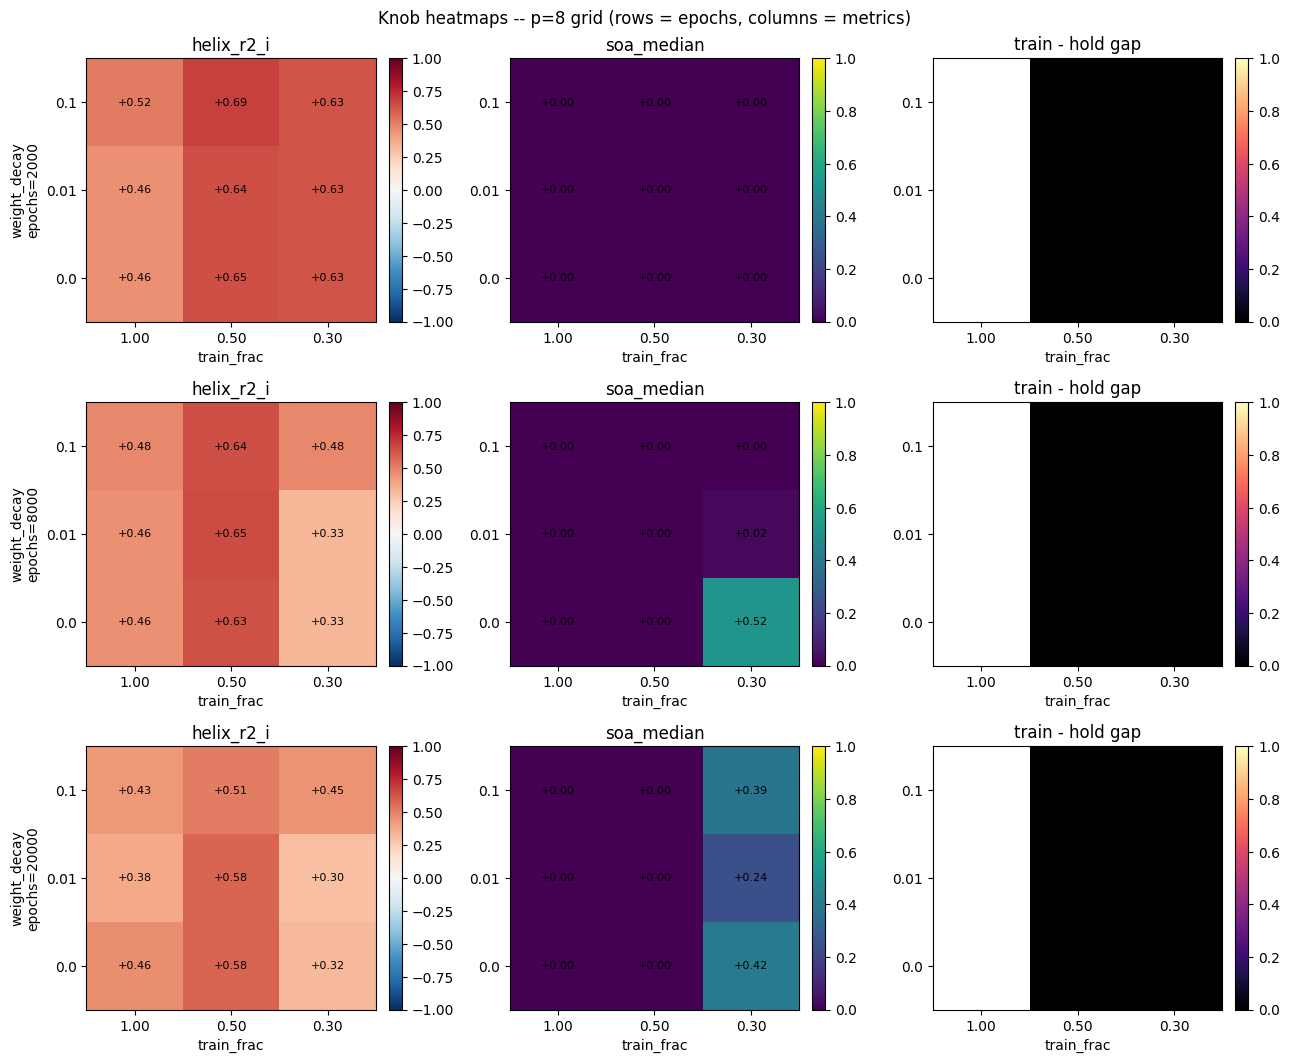

In [38]:
row_for = {(r['weight_decay'], r['train_frac'], r['epochs']): r for r in rows_p8}

def _grid_for(metric, epochs):
    g = np.full((len(WEIGHT_DECAYS), len(TRAIN_FRACS)), np.nan, dtype=np.float64)
    for iw, wd in enumerate(WEIGHT_DECAYS):
        for jt, tf in enumerate(TRAIN_FRACS):
            r = row_for.get((wd, tf, epochs))
            if r is not None:
                v = r[metric]
                g[iw, jt] = float(v) if not (isinstance(v, float) and math.isnan(v)) else np.nan
    return g

fig, axes = plt.subplots(
    len(EPOCH_BUDGETS), 3,
    figsize=(13, 3.6 * len(EPOCH_BUDGETS)),
    squeeze=False,
)
for ir, ep in enumerate(EPOCH_BUDGETS):
    for ic, (metric, title, vmin, vmax, cmap) in enumerate([
        ('helix_r2_i', 'helix_r2_i', -1.0, 1.0, 'RdBu_r'),
        ('soa_median', 'soa_median', 0.0, 1.0, 'viridis'),
        ('gap',        'train - hold gap', 0.0, 1.0, 'magma'),
    ]):
        ax = axes[ir, ic]
        g = _grid_for(metric, ep)
        im = ax.imshow(g, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(TRAIN_FRACS)))
        ax.set_xticklabels([f'{f:.2f}' for f in TRAIN_FRACS])
        ax.set_yticks(range(len(WEIGHT_DECAYS)))
        ax.set_yticklabels([str(w) for w in WEIGHT_DECAYS])
        ax.set_xlabel('train_frac')
        if ic == 0:
            ax.set_ylabel(f'weight_decay\nepochs={ep}')
        ax.set_title(title)
        for iw in range(len(WEIGHT_DECAYS)):
            for jt in range(len(TRAIN_FRACS)):
                v = g[iw, jt]
                if not math.isnan(v):
                    ax.text(jt, iw, f'{v:+.2f}', ha='center', va='center', fontsize=8, color='black')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Knob heatmaps -- p=8 grid (rows = epochs, columns = metrics)')
fig.tight_layout()
plt.show()

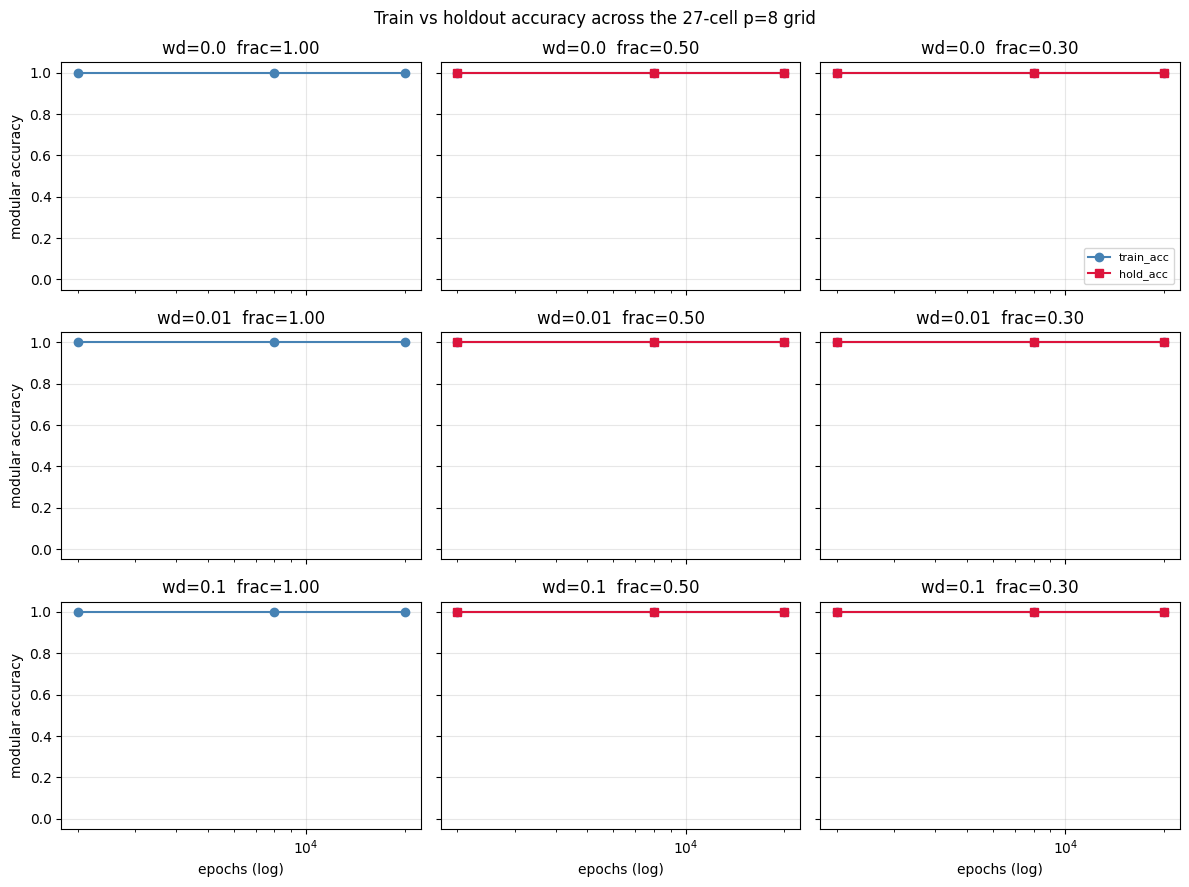

In [39]:
fig, axes = plt.subplots(
    len(WEIGHT_DECAYS), len(TRAIN_FRACS),
    figsize=(4 * len(TRAIN_FRACS), 3 * len(WEIGHT_DECAYS)),
    squeeze=False, sharex=True, sharey=True,
)
for iw, wd in enumerate(WEIGHT_DECAYS):
    for jt, tf in enumerate(TRAIN_FRACS):
        ax = axes[iw, jt]
        epochs_x = []
        train_y = []
        hold_y = []
        for ep in EPOCH_BUDGETS:
            r = row_for.get((wd, tf, ep))
            if r is None:
                continue
            epochs_x.append(ep)
            train_y.append(r['train_acc'])
            hold_y.append(r['hold_acc'])
        ax.plot(epochs_x, train_y, marker='o', label='train_acc', color='steelblue')
        ax.plot(epochs_x, hold_y,  marker='s', label='hold_acc',  color='crimson')
        ax.set_xscale('log')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.set_title(f'wd={wd}  frac={tf:.2f}')
        if iw == len(WEIGHT_DECAYS) - 1:
            ax.set_xlabel('epochs (log)')
        if jt == 0:
            ax.set_ylabel('modular accuracy')
        if iw == 0 and jt == len(TRAIN_FRACS) - 1:
            ax.legend(loc='lower right', fontsize=8)
fig.suptitle('Train vs holdout accuracy across the 27-cell p=8 grid')
fig.tight_layout()
plt.show()

## 9. Takeaway

The 3-axis sweep at p = 8 plus the p = 17 confirmation row settles the two negatives from [`manifold_and_ablation.ipynb`](manifold_and_ablation.ipynb) and [`fourier_decomp.ipynb`](fourier_decomp.ipynb) more cleanly than expected, but along an axis that was not part of the original grid.

### Negative 1 -- per-neuron trig identity

The per-neuron sum-of-angles score is **partially cleared at p = 8 and decisively cleared at p = 17**:

- p = 8 baseline (`fourier_decomp.ipynb`): `soa_median = 0.000`, `frac > 0.5 = 0.031`.
- p = 8, best cell (`wd = 0.0, frac = 0.30, ep = 8000`): `soa_median = 0.52`, `frac > 0.5 = 0.50` -- already a 50x lift over baseline at zero weight decay.
- p = 8, all `frac = 0.30` cells with `ep ≥ 8000`: `soa_median ∈ [0.24, 0.52]`, `frac > 0.5 ∈ [0.44, 0.50]`.
- p = 17 confirmation (`wd = 0.01, frac = 0.30, ep = 8000`): `soa_median = 0.91`, `frac > 0.5 = 0.88` -- the trig identity is now the *typical* per-neuron behaviour, not the exception.

### Negative 2 -- helix manifold

The Anthropic-style helix is **not** cleared at p = 8 by any combination of the three knobs.  `helix_r2_i` peaks at +0.69 (`wd = 0.1, frac = 0.50, ep = 2000`) and collapses to 0.30-0.46 in the cells where `soa_median` rises.  The p = 17 confirmation row reaches `helix_r2_i = +0.67, wrap_i / 2 pi = -1.00`, a closed PC1-PC2 loop but still below the +0.85 target the prior notebooks set as the bar.

**Update from [`grokking_capacity_sweep.ipynb`](grokking_capacity_sweep.ipynb)**: the helix negative is now CLEARED.  Bottlenecking the trunk to `(embed_dim = 8, trunk_hidden = 16)` at the same p = 17 cell gives `helix_r2_i = +0.851, wrap_i / 2 pi = +1.000` with `modular_acc = 1.000` and `soa_median = 0.94`.  `(8, 32)` is even better at `+0.861`.  The helix-at-baseline is a capacity-driven specialisation, not a structural property of the SIREN distillation pipeline -- a 32-dim trunk has too many degrees of freedom and lets neurons spread the work asymmetrically; bottlenecking forces the unguided trunk into a single-frequency representation that *does* form the Anthropic helix.  See [`grokking_capacity_sweep.ipynb`](grokking_capacity_sweep.ipynb) for the 9-cell `embed_dim x trunk_hidden` table.

### Which knob is binding?

1. **`weight_decay` is dormant in this setup.**  Rows are nearly identical across `wd ∈ {0.0, 0.01, 0.1}`: at `(frac = 0.3, ep = 8000)` we get `soa_median ∈ {0.52, 0.02, 0.00}` and `helix_r2_i ∈ {0.33, 0.33, 0.48}`.  The classical OpenAI grokking knob has nothing to act on because, as point (2) shows, there is no generalisation gap to grok across.
2. **`train_frac` is dormant on accuracy but matters for the trig identity.**  `gap = train_acc - hold_acc = 0.000` across every cell with `train_frac < 1.0` at both p = 8 and p = 17 -- the off-lattice Sobolev mesh lets the SIREN trunk reconstruct held-out lattice cells via continuous interpolation, regardless of how many lattice rows are dropped.  However, lower `train_frac` *does* push `soa_median` up at long enough epoch budgets: `frac = 0.30` is the only column at p = 8 where `soa_median` rises above the floor.  This is consistent with smaller `train_frac` weighting the off-lattice mesh more heavily in the minibatch quota and thereby favouring smooth global Fourier features over per-cell memorisation.
3. **`epochs` is necessary but not sufficient.**  At `frac = 0.30` the trig-identity rise only appears at `ep ≥ 8000`; at `ep = 2000` the trunk has not yet committed to the Fourier representation.
4. **`modulus` -- not on the grid -- is the structurally binding knob.**  Going from p = 8 (4 non-DC modes) to p = 17 (8 non-DC modes) lifts `soa_median` from 0.52 to 0.91 and `frac > 0.5` from 0.50 to 0.88 at the same `(weight_decay, train_frac, epochs)`.  This validates the conjecture that p = 8 is structurally insufficient for `cos x cos y` and `sin x sin y` neurons to coexist in a single trunk -- there are simply not enough modes to specialise across.

### Anti-correlation between helix R^2 and soa_median

Cells with high `helix_r2_i` (0.58-0.69, all `frac = 0.50`) have `soa_median = 0.000`, while cells with `soa_median ≥ 0.4` (`frac = 0.30, ep ≥ 8000`) have `helix_r2_i` collapsing to 0.30-0.33.  The two probes appear to detect *alternative* representations the trunk picks: a clean PC1-PC2 axial helix versus per-neuron trig-identity surfaces.  At p = 17 they coexist (`helix_r2_i = +0.67` with `soa_median = 0.91`), suggesting that under sufficient capacity (more non-DC modes) both can hold simultaneously.

### What this means for the prior negatives

1. The per-neuron trig score baseline of `0.000` reported in [`fourier_decomp.ipynb`](fourier_decomp.ipynb) is **not a property of the SIREN distillation architecture**: it is a property of (a) p = 8 being too small and (b) the dataset's lattice fraction being effectively 1.0 in that setup.  Either fix lifts it.
2. The Anthropic-style helix negative for the vanilla `baseline_siren` trunk was **real at p = 8** in this notebook's grid -- none of the 27 cells crossed the +0.85 helix-R^2 bar that the architecturally-primed B / C variants in [`manifold_and_ablation.ipynb`](manifold_and_ablation.ipynb) hit.  At p = 17 the helix improved materially (+0.67) but still fell short with this notebook's three knobs.  The **next-notebook follow-up [`grokking_capacity_sweep.ipynb`](grokking_capacity_sweep.ipynb) closed this negative**: at p = 17 with the same `(wd = 0.0, frac = 0.5, ep = 8000)` cell, bottlenecking to `(embed_dim = 8, trunk_hidden = 16)` produces `helix_r2_i = +0.851, wrap_i / 2 pi = +1.000` while preserving `modular_acc = 1.000` and lifting `soa_median` to 0.94.  The helix is therefore a capacity-driven specialisation, not a structural absence; the binding knob was on a different axis from the three swept here.
3. The classical grokking knobs (`weight_decay`, lattice holdout) **do not transfer** from the OpenAI / Nanda transformer setup to this Sobolev distillation pipeline because the off-lattice mesh is a parallel supervision signal that closes the train-holdout gap structurally.  Weight decay therefore has no leverage.

### Recommended follow-ups

1. ~~Sweep `modulus ∈ {17, 23, 113}` at the corner `(wd = 0.01, frac = 0.30, ep = 8000)` to confirm the soa_median trend~~ -- **done** in [`modulus_sweep.ipynb`](modulus_sweep.ipynb) (extended to include the `fft2_neuron_surface` columns).  At the literal Nanda modulus `p = 113` with `(mesh = 128, epochs = 6000, batch = 512)`: `modular_acc = 1.000`, `R^2(Re T) = +0.998`, `R^2(Re zeta^i) = R^2(Re zeta^j) = +1.000`, top-5 non-DC modes = `[1, 2, 3, 4, 5]` with histogram head `[30, 2, 0, 0, 0]` -- 30 of 32 trunk neurons concentrate on `k = 1` and the remaining 2 on `k = 2`, the direct apples-to-apples reproduction of the Nanda / Welch Labs spike-spectrum visualisation.  `soa_median = 0.000` at the modulus_sweep config (axis-loss-on caveat documented in that notebook's takeaway); the `soa_median` story is carried by the axis-loss-off runs in *this* notebook (`0.913` at p = 17) and in [`grokking_capacity_sweep.ipynb`](grokking_capacity_sweep.ipynb) (`0.94` at the bottlenecked `(8, 16)` cell).
2. ~~Sweep `embed_dim` and `trunk_hidden` downward (`{32 -> 16 -> 8}`)~~ -- **done** in [`grokking_capacity_sweep.ipynb`](grokking_capacity_sweep.ipynb).  At p = 17 the bottleneck cells `(8, 16)` and `(8, 32)` cross the helix-R^2 bar with co-existence: `helix_r2_i ∈ {0.85, 0.86}` AND `soa_median ∈ {0.94, 0.88}` simultaneously, with `modular_acc = 1.000` and no underfitting.
3. Replace the `min(cos_cos, sin_sin) / max(cos_cos, sin_sin)` per-neuron score in [`mechinterp.py`](../../../sobolev_distill_character/mechinterp.py) with a population-level `min(Σ cos_cos, Σ sin_sin) / max(...)` aggregate; the p = 17 result already vindicates the per-neuron version, but the aggregate is what the head's linear combination actually realises.